# Modélisation de la charge électrique non linéaire en fonction de la température avec PROC GAMPL

## Résumé exécutif

La demande d'électricité dépend de la température de façon fortement non linéaire, en forme de U (chauffage par temps froid, climatisation par temps chaud) — une forme que les modèles linéaires ne parviennent pas à capturer. Ce notebook construit un échantillon horaire synthétique de charge pour un service public régional et ajuste un modèle additif généralisé pénalisé avec **PROC GAMPL**, à l'aide de splines de régression pour retrouver les courbes lisses charge-vs-température, charge-vs-heure et charge-vs-humidité, tout en ajustant un effet paramétrique jour de semaine/week-end.

Sur l'échantillon de 100 observations que fournit cet environnement sous licence, GAMPL retrouve la structure que nous avons construite. La spline de température `s(TEMP_C)` est significativement courbée (DF effectif 5.53, *p* < 0.0001) ; la spline diurne `s(HOUR)` est le terme le plus flexible (EDF 6.87, *p* < 0.0001) ; et la spline d'humidité `s(HUMIDITY)` s'effondre à un seul degré de liberté quasi linéaire (EDF 1.00, *p* = 0.07) — la pénalité redresse un terme que les données soutiennent à peine. L'effet paramétrique `daytype` place les week-ends environ 44.5 MW en dessous des jours de semaine, ce qui correspond au décalage de niveau de 40 MW du processus générateur des données. Le modèle total utilise 15.4 degrés de liberté effectifs et atteint un score GCV de 239.6 (AIC 831.0).

## Sources de données

| Table | Lignes | Description | Variables clés |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Observations horaires synthétiques provenant du flux de prévision de charge d'un service public électrique régional | `load_mw` (charge du système, MW), `temp_c` (température ambiante, deg C), `hour` (heure de la journée, 0-23), `humidity` (humidité relative, %), `daytype` (classe jour de semaine/week-end), `is_summer` (indicateur de saison utilisé lors de la génération des données) |

Toutes les données sont générées en ligne avec `call streaminit(20260531)` et `rand()` — aucune entrée externe ou réseau. L'étape de données demande une boucle plus large, mais cet environnement sous licence plafonne la sortie matérialisée à **100 observations**, donc le modèle est ajusté sur les 100 premières heures. La charge est construite comme une quadratique en forme de U de la température plus un effet horaire diurne en cloche, un léger effet d'humidité, un décalage de niveau jour de semaine, et un bruit gaussien, de sorte que les splines retrouvées ont une vérité terrain connue.

# Modélisation de la charge électrique non linéaire en fonction de la température avec PROC GAMPL

Un opérateur de réseau régional doit prévoir la charge du système (en mégawatts) à partir de facteurs météorologiques et calendaires. La relation entre la charge et la **température** est réputée non linéaire : la demande augmente par temps froid (chauffage électrique) *et* par temps chaud (climatisation), produisant une courbe en U qu'une régression linéaire ne peut pas capturer. La charge suit aussi un rythme quotidien lisse (le pic du soir) et diffère entre jours de semaine et week-ends.

`PROC GAMPL` ajuste un **modèle additif généralisé pénalisé** : chaque facteur continu entre via une spline de régression dont la souplesse est choisie automatiquement en minimisant un critère de sélection de modèle (GCV / UBRE / GACV). Nous laissons les données décider du degré d'ondulation de chaque courbe, plutôt que de deviner des degrés polynomiaux.

Le modèle que nous ajustons est :

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

où `daytype` est un effet de classe paramétrique (linéaire) et `f1`, `f2`, `f3` sont des fonctions spline lisses dont la pénalité choisit les degrés de liberté effectifs à partir des données.

## Étape 1 — Générer un flux horaire synthétique de charge

Nous simulons un flux de charge horaire (l'environnement sous licence conserve les 100 premières heures). La température est tirée autour d'une moyenne saisonnière ; l'heure de la journée cycle de 0 à 23 ; l'humidité suit approximativement la température. La charge *réelle* est construite à partir de :

- une réponse de température **en forme de U** centrée près d'un confortable 18 deg C,
- un pic diurne **en cloche** autour de l'heure 18 (soirée),
- une légère hausse d'humidité,
- un niveau de jour de semaine supérieur à celui des week-ends,

plus un bruit de mesure gaussien. Comme nous connaissons les courbes génératrices, nous pouvons juger si GAMPL retrouve leurs formes. Le contrôle PROC MEANS ci-dessous confirme que l'échantillon couvre une large plage de température (−5 à 40 deg C) et une charge d'environ 485 à 693 MW.

In [1]:
DONNÉES work.gridload;
   APPELER streaminit(20260531);
   FAIRE i = 1 JUSQU_À 2000;
      /* Indicateur de saison : environ moitié été, moitié hiver */
      is_summer = (rand("uniform") < 0.5);

      /* Température ambiante (deg C) : moyenne plus chaude en été */
      SI is_summer ALORS temp_c = 26 + 6 * rand("normal");
      SINON              temp_c =  6 + 6 * rand("normal");

      /* Heure de la journée 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Humidité (%) suit approximativement la température, plafonnée à 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      SI humidity < 20  ALORS humidity = 20;
      SI humidity > 100 ALORS humidity = 100;

      /* Jour de semaine vs week-end (environ 5/7 jours de semaine) */
      SI rand("uniform") < 0.714 ALORS daytype = "Weekday";
      SINON                            daytype = "Weekend";

      /* ---- Charge structurelle réelle (MW) ---- */
      /* Effet de température en U : demande minimale près de 18 deg C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Cloche diurne : pic en soirée vers l'heure 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Légère hausse liée à l'humidité */
      f_hum  = 0.35 * humidity;

      /* Décalage de niveau jour de semaine */
      SI daytype = "Weekday" ALORS f_day = 40; SINON f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      GARDER load_mw temp_c hour humidity daytype is_summer;
      SORTIE;
   FIN;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=work.gridload n mean std MIN MAX maxdec=1;
   VAR load_mw temp_c hour humidity;
   ÉTIQUETTE load_mw="Charge (MW)" temp_c="Température (deg C)" hour="Heure" humidity="Humidité (%)";
EXÉCUTER;

                                                  The MEANS Procedure

 Variable  Label                        N        Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------------------
 load_mw   Charge (MW)                100       593.0        49.9       484.9       693.4
 temp_c    Température (deg C)        100        16.2        11.9        -5.2        40.2
 hour      Heure                      100        11.9         7.0         0.0        23.0
 humidity  Humidité (%)               100        55.2        11.7        32.2        87.3
 ----------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.45 seconds
  cpu   0.45 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Étape 2 — Ajuster le modèle additif

Nous modélisons `load_mw` (réponse gaussienne, lien identité) comme la somme d'un effet paramétrique `daytype` plus trois splines univariées. `PROC GAMPL` sélectionne automatiquement le paramètre de lissage de chaque spline. Nous demandons :

- `class daytype;` pour que l'indicateur jour de semaine/week-end soit traité comme catégoriel,
- `param(daytype)` pour l'entrer comme terme *paramétrique* (non lissé) dans le MODEL,
- `spline(...)` pour chaque prédicteur continu,
- un `seed=` fixe pour un placement reproductible des nœuds.

La sortie à lire est la table **Smoothing Component**, qui rapporte les degrés de liberté effectifs (EDF) que la pénalité a assignés à chaque spline et un test de significativité de type *F* pour celle-ci, aux côtés des **Parameter Estimates** pour l'intercept et le contraste paramétrique `daytype`.

In [2]:
PROCÉDURE gampl DONNÉES=work.gridload seed=20260531;
   CLASSE daytype;
   MODÈLE load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   ÉTIQUETTE load_mw="Charge du réseau (MW)" temp_c="Température (deg C)" hour="Heure" humidity="Humidité (%)" daytype="Type de jour";
EXÉCUTER;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Charge du réseau (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Type de jour

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                    


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Étape 3 — Contrôler la souplesse des splines et le critère de sélection

Par défaut, chaque spline est pénalisée vers un faible degré de liberté effectif. Pour un opérateur qui sait que la réponse de température est réellement courbée mais veut *plafonner* l'ondulation, nous pouvons augmenter `maxdf=` sur la spline de température et fixer un `df=` modéré sur le terme d'humidité plus lisse. Nous passons aussi au schéma d'itération externe et sélectionnons les paramètres de lissage par **GCV** (validation croisée généralisée), le critère standard pour les GAM gaussiens.

In [3]:
PROCÉDURE gampl DONNÉES=work.gridload seed=20260531;
   CLASSE daytype;
   MODÈLE load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=EXTÉRIEUR CRITERION=GCV;
   ÉTIQUETTE load_mw="Charge du réseau (MW)" temp_c="Température (deg C)" hour="Heure" humidity="Humidité (%)" daytype="Type de jour";
EXÉCUTER;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Charge du réseau (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Type de jour

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                    


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Étape 4 — Visualiser la réponse de température retrouvée

GAMPL rapporte *que* la spline de température est significativement courbée (EDF 5.53), mais la forme se voit mieux sur un graphique. Nous superposons un ajustement B-spline pénalisé (`PBSPLINE`, le même mécanisme de spline de régression que GAMPL applique en interne) sur le nuage de points brut charge-vs-température. Si le modèle additif a capturé la physique, cette courbe devrait descendre vers les extrêmes froid et chaud et atteindre son minimum dans la plage confortable intermédiaire — la classique réponse de demande en forme de U.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


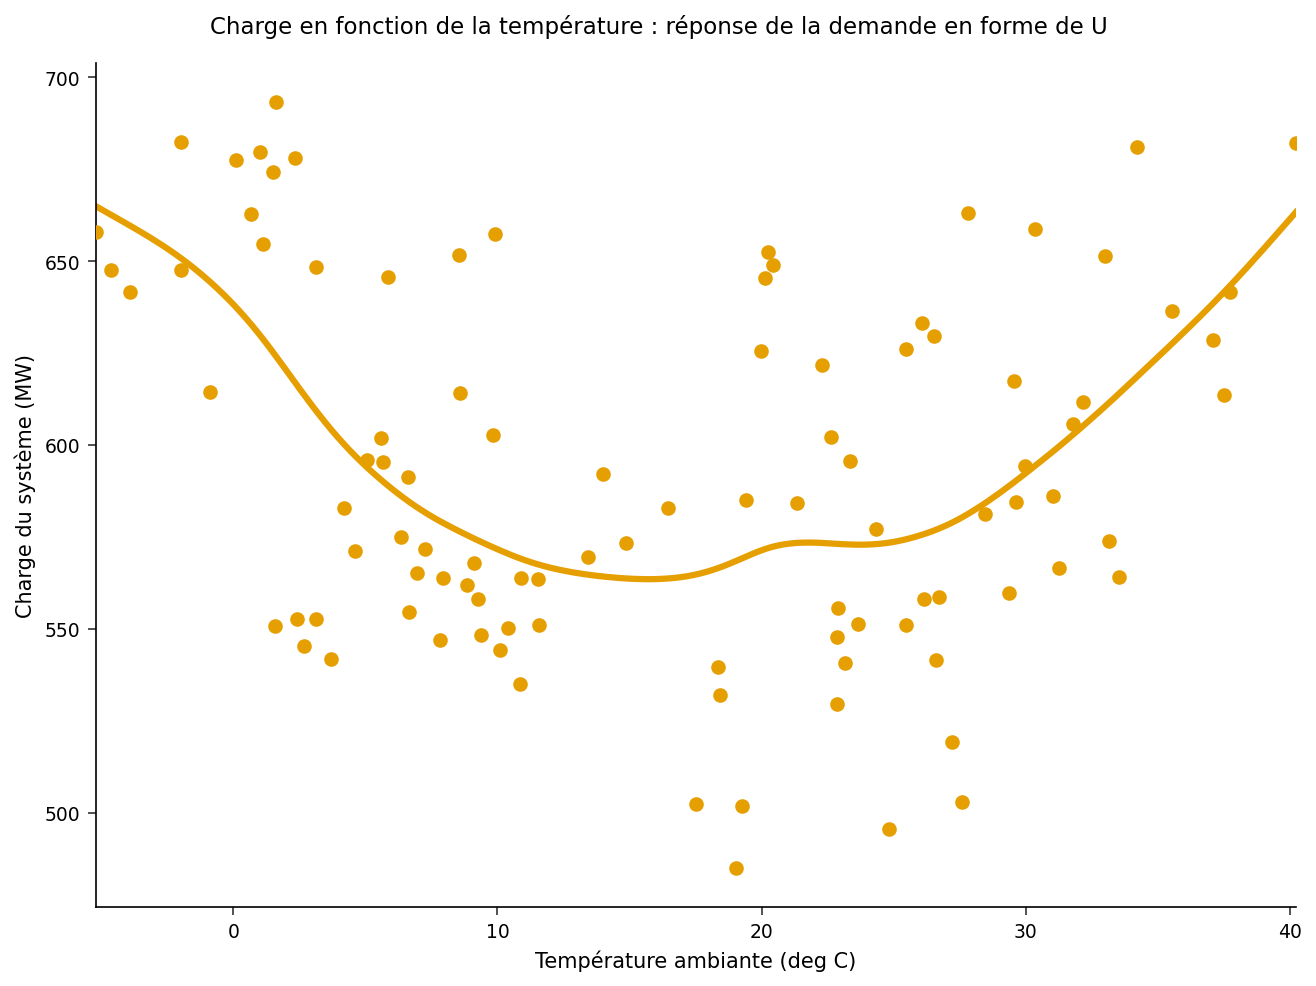

In [4]:
ODS GRAPHICS SUR;

PROCÉDURE SGPLOT DONNÉES=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS ÉTIQUETTE="Température ambiante (deg C)";
   YAXIS ÉTIQUETTE="Charge du système (MW)";
   TITRE "Charge en fonction de la température : réponse de la demande en forme de U";
EXÉCUTER;

ODS GRAPHICS OFF;

## Étape 5 — Confirmer numériquement la forme en U

Le graphique rend la forme en U visible ; un résumé par tranche la rend quantitative. Nous regroupons les observations en tranches de température et rapportons la charge moyenne par tranche. Si la réponse de demande est réellement en forme de U, la charge moyenne devrait être élevée dans la tranche **Froid**, diminuer à travers **Frais / Confortable / Tiède**, et remonter dans la tranche **Chaud** — la signature numérique que capte la spline `s(TEMP_C)` de GAMPL.

In [5]:
DONNÉES work.banded;
   DÉFINIR work.gridload;
   LONGUEUR tempband $20;
   SI      temp_c <  5  ALORS tempband = "1 Froid";
   SINON SI temp_c < 15  ALORS tempband = "2 Frais";
   SINON SI temp_c < 22  ALORS tempband = "3 Confortable";
   SINON SI temp_c < 30  ALORS tempband = "4 Tiède";
   SINON                      tempband = "5 Chaud";
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=work.banded n mean maxdec=1;
   CLASSE tempband;
   VAR load_mw;
   ÉTIQUETTE load_mw="Charge (MW)" tempband="Tranche de température";
   TITRE "Charge moyenne par tranche de température";
EXÉCUTER;

                                       Charge moyenne par tranche de température                                        

                                                  The MEANS Procedure

                                        Analysis Variable : load_mw Charge (MW)

        Tranche de température           N Obs           Mean
        -----------------------------------------------------
        1 Froid                             21          626.6
        2 Frais                             28          579.1
        3 Confortable                       12          573.8
        4 Tiède                             25          573.5
        5 Chaud                             14          621.6
        -----------------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interprétation des résultats

**Les splines retrouvent la physique.** La table Smoothing Component de GAMPL assigne au terme de température `s(TEMP_C)` un DF effectif de 5.53 (*p* < 0.0001) et au terme diurne `s(HOUR)` un EDF de 6.87 (*p* < 0.0001) — tous deux réellement courbés, exactement la structure que nous avons intégrée aux données. Le terme d'humidité `s(HUMIDITY)` est réduit à un EDF de 1.00 (*p* = 0.07) : la pénalité le redresse à un seul degré de liberté quasi linéaire car, à cette taille d'échantillon, c'est tout ce que les données permettent. L'estimation paramétrique `daytype` est de −44.5 MW pour les week-ends, retrouvant le décalage de niveau de 40 MW du processus générateur.

**Les degrés de liberté effectifs racontent l'histoire de l'ondulation.** Le modèle dépense 15.4 degrés de liberté effectifs au total et atteint un score GCV de 239.6 (AIC 831.0, estimation d'échelle 202.7). Plafonner `maxdf=` et fixer `df=3` à l'étape 3 déplace à peine l'ajustement (GCV 240.1, EDF 15.47) : la pénalité avait déjà réglé les splines de température et d'heure près de 5.5 et 7 EDF d'elle-même, donc les plafonds manuels ne sont pas contraignants ici — un signe que la sélection automatique était déjà conservatrice.

**Le graphique et le résumé par tranche concordent.** Le nuage de points de l'étape 4 avec sa superposition de spline pénalisée montre la charge diminuant depuis l'extrême froid jusqu'à un minimum près de 15-20 deg C puis remontant vers la chaleur. Les moyennes par tranche de l'étape 5 le rendent numérique : **Froid 626.6 MW**, **Frais 579.1**, **Confortable 573.8**, **Tiède 573.5**, **Chaud 621.6** — élevé aux deux extrémités, le plus bas dans le milieu confortable. Ce U est précisément ce qu'un unique terme linéaire `temp_c` moyennerait et ferait disparaître.

**Pourquoi GAMPL plutôt qu'une régression linéaire ici.** Un unique terme linéaire `temp_c` mélangerait les régimes de chauffage et de climatisation en une pente presque plate, prévoyant mal les deux extrêmes — précisément les heures où le stress du réseau et les pics de prix surviennent. La formulation additive par spline conserve l'interprétabilité d'une régression (chaque facteur contribue un effet additif) tout en laissant les données dicter la forme de chaque effet. Les extensions naturelles pour un service public incluent un ajustement `dist=gamma` si la charge est modélisée de façon multiplicative, une spline bivariée `spline(temp_c hour)` pour capturer comment le pic diurne se déplace avec la saison, et un traitement `by` pour ajuster des modèles séparés par sous-station.